In [27]:
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np 
import os,cv2

def plot_gallery(images,titles,h,w,n_row=3,n_col=4):
    plt.figure(figsize=(1.8*n_col,2.4*n_row))
    plt.subplots_adjust(bottom=0,left=.01,right=.99,top=.90,hspace=.35)
    for i in range(n_row*n_col):
        plt.subplot(n_row,n_col,i+1)
        plt.imshow(images[i].reshape((h,w)),cmap=plt.cm.gray)
        plt.title(titles[i],size=12)
        plt.xticks(())
        plt.yticks(())

In [28]:
# --- 1. SETUP PATH ---
dir_name = r"C:\Users\Amina Rafi\Downloads\dataset\dataset\faces"

# Initialize variables
y = []
X = []
target_names = []
person_id = 0
h = w = 300
n_samples = 0
class_names = []

# --- 2. LOAD IMAGES ---
if os.path.exists(dir_name):
    for person_name in os.listdir(dir_name):
        dir_path = os.path.join(dir_name, person_name)

        if os.path.isdir(dir_path):
            class_names.append(person_name)
            for image_name in os.listdir(dir_path):
                image_path = os.path.join(dir_path, image_name)
                img = cv2.imread(image_path)
                
                if img is not None:
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    resized_image = cv2.resize(gray, (h, w))
                    v = resized_image.flatten()
                    X.append(v)
                    n_samples = n_samples + 1
                    y.append(person_id)
                    target_names.append(person_name)
            person_id = person_id + 1

# Convert to numpy arrays
y = np.array(y)
X = np.array(X)
target_names = np.array(target_names)
n_features = X.shape[1]
n_classes = person_id

# --- 3. PRINT OUTPUT (CLEAN) ---
print("Data Loaded Successfully!")
print(y.shape, X.shape, target_names.shape)
print("Number of samples:", n_samples)
print("n_classes:", person_id)

print("Total dataset size:")
print("n_samples:%d" % n_samples)
print("n_features: %d" % n_features)
print("n_classes: %d" % n_classes)

# --- 4. PCA & ANN (SILENT MODE) ---
if n_samples > 0:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

    # PCA
    n_components = 50
    pca = PCA(n_components=n_components, whiten=True)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # ANN - verbose=False stops the "Iteration 1, 2, 3..." logs
    clf = MLPClassifier(hidden_layer_sizes=(1024,), batch_size=256, verbose=False, early_stopping=True)
    clf.fit(X_train_pca, y_train)

    y_pred = clf.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    # Only print final result
    print(f"Final Accuracy: {accuracy * 100:.2f}%")

Data Loaded Successfully!
(450,) (450, 90000) (450,)
Number of samples: 450
n_classes: 9
Total dataset size:
n_samples:450
n_features: 90000
n_classes: 9


C:\Users\Amina Rafi\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


Final Accuracy: 58.33%


Extracting the top 150 eigenfaces from 337 faces


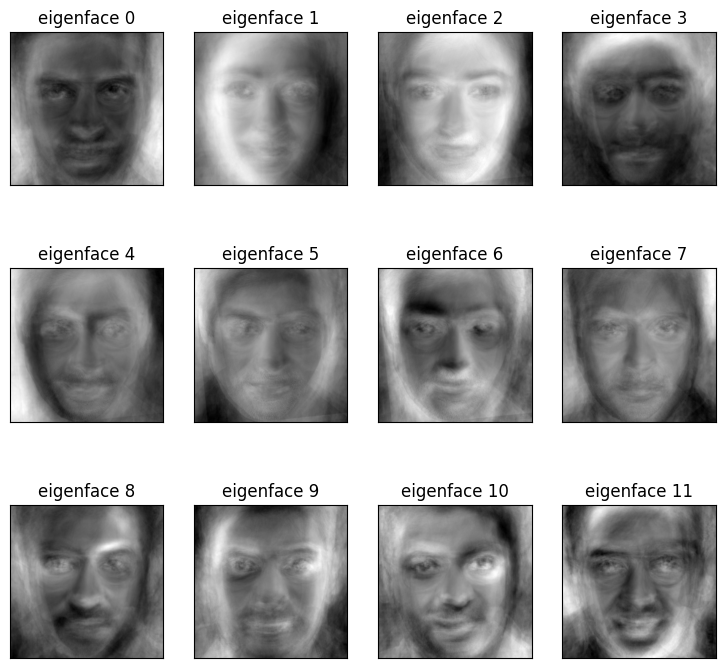

Projecting the input data on the eigenfaces orthonormal basis
(337, 150) (113, 150)
Performing LDA...
Project done... LDA projection successful.


In [29]:
# --- Helper Function to Plot Images (You need to define this!) ---
def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

# --- Your Logic (Corrected) ---

# 1. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

n_components = 150

print("Extracting the top %d eigenfaces from %d faces" % (n_components, X_train.shape[0]))

# 2. PCA (Fixed typo: n_components)
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True).fit(X_train)

# 3. Eigenfaces
eigenfaces = pca.components_.reshape((n_components, h, w))
eigenface_titles = ["eigenface %d" % i for i in range(eigenfaces.shape[0])]

# 4. Plotting (Now works because we defined plot_gallery above)
plot_gallery(eigenfaces, eigenface_titles, h, w)
plt.show() 

print("Projecting the input data on the eigenfaces orthonormal basis")
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(X_train_pca.shape, X_test_pca.shape)

# 5. LDA (Linear Discriminant Analysis)
print("Performing LDA...")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_pca, y_train)
X_train_lda = lda.transform(X_train_pca)
X_test_lda = lda.transform(X_test_pca)

print("Project done... LDA projection successful.")

In [30]:
clf=MLPClassifier(random_state=1,hidden_layer_sizes=(10,10),max_iter=1000,verbose=True).fit(X_train_lda,y_train)
print("Model Weights:")
model_info=[coef.shape for coef in clf.coefs_]
print(model_info)

Iteration 1, loss = 3.01041086
Iteration 2, loss = 2.95455688
Iteration 3, loss = 2.90414150
Iteration 4, loss = 2.85194376
Iteration 5, loss = 2.80050524
Iteration 6, loss = 2.75319549
Iteration 7, loss = 2.70407206
Iteration 8, loss = 2.65775624
Iteration 9, loss = 2.61422920
Iteration 10, loss = 2.57107557
Iteration 11, loss = 2.52855053
Iteration 12, loss = 2.48917782
Iteration 13, loss = 2.44943192
Iteration 14, loss = 2.41308813
Iteration 15, loss = 2.37521559
Iteration 16, loss = 2.33944972
Iteration 17, loss = 2.30515439
Iteration 18, loss = 2.26978977
Iteration 19, loss = 2.23931842
Iteration 20, loss = 2.20639923
Iteration 21, loss = 2.17671969
Iteration 22, loss = 2.14569599
Iteration 23, loss = 2.11627404
Iteration 24, loss = 2.08717485
Iteration 25, loss = 2.05961046
Iteration 26, loss = 2.03286629
Iteration 27, loss = 2.00541186
Iteration 28, loss = 1.97915997
Iteration 29, loss = 1.95339364
Iteration 30, loss = 1.92773869
Iteration 31, loss = 1.90283991
Iteration 32, los

Accuracy: 67.2566371681416


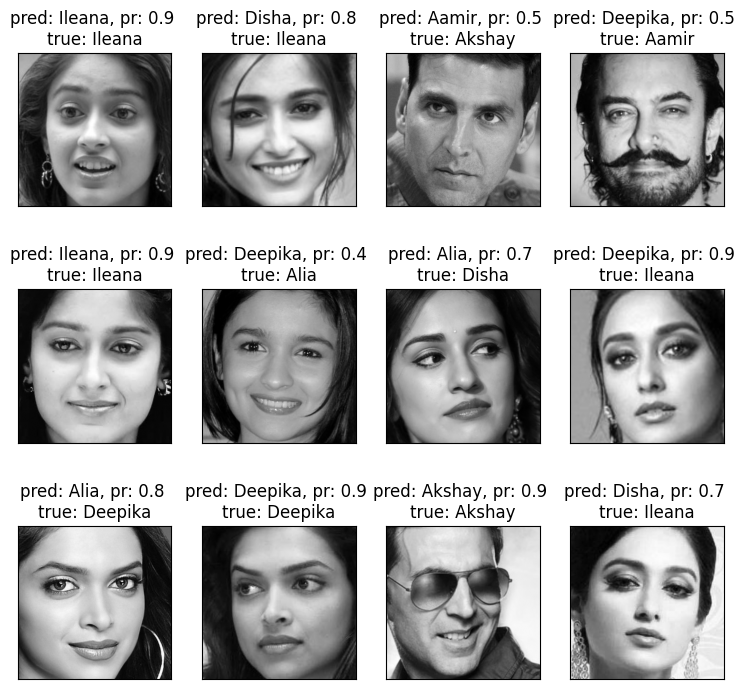

In [31]:
y_pred=[];y_prob=[]
for test_face in X_test_lda:
    prob=clf.predict_proba([test_face])[0]
    class_id=np.where(prob==np.max(prob))[0][0]
    y_pred.append(class_id)
    y_prob.append(np.max(prob))
y_pred=np.array(y_pred)

prediction_titles=[]
true_positive=0
for i in range(y_pred.shape[0]):
    true_name=class_names[y_test[i]]
    pred_name=class_names[y_pred[i]]
    result='pred: %s, pr: %s \ntrue: %s' % (pred_name, str(y_prob[i])[0:3],true_name)
    prediction_titles.append(result)
    if true_name==pred_name:
        true_positive=true_positive+1
print("Accuracy:",true_positive*100/y_pred.shape[0])
plot_gallery(X_test,prediction_titles,h,w)
plt.show()